In [1]:
from ua_datasets import NewsClassificationDataset


train_data = NewsClassificationDataset(root='data/', split='train', return_tags=True)
test_data = NewsClassificationDataset(root='data/', split='test', return_tags=True)

X_train = []
X_test = []
y_train = []
y_test = []

for title, _, tag, _ in train_data:
    X_train.append(title)
    y_train.append(tag)

for title, _, tag, _ in test_data:
    X_test.append(title)
    y_test.append(tag)




In [2]:
import requests
import bs4
import re 


def get_page(url: str) -> str:
    """
    Завантажує HTML-код сторінки за URL.
    
    Args:
        url (str): адреса сторінки
    
    Returns:
        str: HTML-код сторінки
    """
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/116.0.0.0 Safari/537.36'
    }
    response = requests.get(url, headers=headers)
    return response.text


def parse(page: str):
    """
    Парсить HTML сторінки і знаходить елементи новин.
    Args:
        page (str): HTML-код сторінки
    Returns:
        list: список тегів <li> з класом 'l-entries__item'
    """
    soup = bs4.BeautifulSoup(page, 'lxml')
    quotes = soup.find_all('li', class_='l-entries__item')
    return quotes


def clean(row: str) -> str:
    """
    Очищає текст новини від службових слів, розривів рядків, ком та зайвих пробілів.
    
    Args:
        row (str): текст новини
    
    Returns:
        str: очищений текст
    """
    cleaned = row.replace("Дата публікації", "")
    cleaned = cleaned.replace("Категорія", "")
    cleaned = cleaned.replace('\n', ' ')
    cleaned = re.sub(r' +', ' ', cleaned).strip()
    cleaned = cleaned.replace(',', '')
    return cleaned


def clean_content(quotes):
    """
    Очищає контент списку тегів новин, пропускає рекламу.
    
    Args:
        quotes (list): список тегів з HTML-контентом
    
    Returns:
        list: список очищених рядків новин
    """
    clean_quotes = []
    for q in quotes:
        c = clean(q.text)
        if c == "Реклама":
            continue
        clean_quotes.append(c)
    return clean_quotes


def save(rows, path: str):
    """
    Зберігає список рядків у файл.
    
    Args:
        rows (list): список рядків для збереження
        path (str): шлях до файлу
    """
    try:
        with open(path, 'w', encoding='utf-8') as f:
            for line in rows:
                f.write(line + '\n')
    except Exception as e:
        print("Could not save the results:", e)
    
def append(rows, path: str):
    """
    Зберігає список рядків у файл.
    
    Args:
        rows (list): список рядків для збереження
        path (str): шлях до файлу
    """
    try:
        with open(path, 'a', encoding='utf-8') as f:
            for line in rows:
                f.write(line + '\n')
    except Exception as e:
        print("Could not save the results:", e)


def proccess_pages(pages: int, url: str) -> str:
    """
    Завантажує HTML код декількох сторінок і об'єднує їх в один рядок.
    
    Args:
        pages (int): кількість сторінок для завантаження
        url (str): базовий URL
    
    Returns:
        str: об'єднаний HTML код всіх сторінок
    """
    page = get_page(url)
    for i in range(2, pages+1):
        page += get_page(url + f"/page-{i}")
    return page



base_url = 'https://tsn.ua/'
topics = {
           "politika",
           "prosport", 
           "nauka_it", 
           "groshi",
           "tsikavinki"
        }
topics_ds = {
    "politika":"політика",
           "prosport":'спорт', 
           "nauka_it":"технології", 
           "groshi":"бізнес",
           "tsikavinki":"новини"
}

print('Обрано інформаційне джерело: ' + base_url)
save([], "result.txt")
for topic in topics_ds.keys():
    page = proccess_pages(50, base_url + topic)
    quotes = parse(page)
    cleaned = clean_content(quotes)
    for i, q in enumerate(cleaned):
        cleaned[i] = topics_ds.get(topic) + ' ' +  q
    append(cleaned, 'result.txt')
    
with open("result.txt", "r") as file:
        lines = set(file.readlines())
with open("unique.txt", "w") as u:
    u.writelines(lines)


Обрано інформаційне джерело: https://tsn.ua/


In [3]:
import re
from collections import Counter
import spacy

nlp = spacy.load("uk_core_news_sm", disable=["ner", "parser"])


def filter(path):
    """
    Зчитує текст з файлу та видаляє службові слова
    (наприклад, 'ТСН', 'Тема') на початку рядків.
    Повертає список очищених рядків.
    """
    with open(path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    for i, l in enumerate(lines):
        split = l.split()
        for _ in range(6):
            if split and (split[0] == 'ТСН' or split[0] == "Тема"):
                split.pop(0)
            if split:
                split.pop(0)
        lines[i] = " ".join(split)
    return lines


def normalize(lines):
    """
    Приводить текст до нижнього регістру
    та видаляє розділові знаки.
    Повертає список нормалізованих рядків.
    """
    normalized_lines = []
    for l in lines:
        normalized = l.lower()
        normalized = re.sub(r"[.,!?;:\"'(){}\[\]<>—–]", '', normalized)
        normalized_lines.append(normalized.strip())
    return normalized_lines


# ===============================
# ТОКЕНІЗАЦІЯ
# ===============================



def tokenize_words(sentences):
    """
    Виконує токенізацію по словах.
    Видаляє пунктуацію, пробіли та числа.
    Повертає список списків слів.
    """
    tokenized = []
    for sentence in sentences:
        doc = nlp(sentence)
        words = [
            token.text
            for token in doc
            if not token.is_punct
            and not token.is_space
            and not token.like_num
        ]
        tokenized.append(words)
    return tokenized



# ===============================
# ВИДАЛЕННЯ СТОП-СЛІВ
# ===============================

def remove_stopwords(tokenized_words):
    """
    Видаляє стоп-слова з токенізованого тексту.
    Повертає список списків слів без стоп-слів.
    """
    cleaned = []
    for sentence in tokenized_words:
        doc = nlp(" ".join(sentence))
        no_stops = [token.text for token in doc if not token.is_stop]
        cleaned.append(no_stops)
    return cleaned


# ===============================
# ЛЕМАТИЗАЦІЯ
# ===============================

def lemmatize(tokenized_words):
    """
    Виконує лематизацію слів.
    Повертає список списків лем.
    """
    lemmatized = []
    for sentence in tokenized_words:
        doc = nlp(" ".join(sentence))
        lemmas = [token.lemma_ for token in doc]
        lemmatized.append(lemmas)
    return lemmatized




def save_to_file(data, filename):
    """
    Зберігає список або текстові дані у файл.
    Якщо передано список списків — об'єднує елементи через пробіл.
    """
    with open(filename, "w", encoding="utf-8") as f:
        if isinstance(data, list):
            for item in data:
                if isinstance(item, list):
                    f.write(" ".join(item) + "\n")
                else:
                    f.write(str(item) + "\n")
        else:
            f.write(str(data))


def preprocess(texts):
    processed = []

    for doc in nlp.pipe(texts, batch_size=1000):
        tokens = [
            token.lemma_
            for token in doc
            if not token.is_stop
            and not token.is_punct
            and not token.is_space
            and not token.like_num
        ]
        processed.append(tokens)

    return processed



In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

def join_tokens(tokens):
    joined = []
    for t in tokens:
        joined.append(" ".join(t))
    return joined


def vectorize(X_train, X_test):
    X_joined = join_tokens(X_train)
    X_test_joined = join_tokens(X_test)

    X_train_tfidf = vectorizer.fit_transform(X_joined)
    X_test_tfidf = vectorizer.transform(X_test_joined)
    return X_train_tfidf, X_test_tfidf

def transform(X):
    X_idfd = vectorizer.transform(X)
    return X_idfd

In [5]:
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC


def filter(path):
    with open(path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    topics = []
    for i, l in enumerate(lines):
        split = l.split()
        topics.append(split.pop(0))
        for _ in range(6):
            
            if split and (split[0] == 'ТСН' or split[0] == "Тема"):
                split.pop(0)
            if split:
                split.pop(0)
        lines[i] = " ".join(split)
    return lines, topics


print("Vectorizing...")
X_train = preprocess(X_train)
X_test = preprocess(X_test)
X_train_tfidf, X_test_tfidf = vectorize(X_train, X_test)
cs = {0.3, 0.5, 1, 2}
print("Training...")
print("Result on ua_datasets test set:")

for c in cs:
    clf = LinearSVC(max_iter=100, C=c)
    clf.fit(X_train_tfidf, y_train)
    pred = clf.predict(X_test_tfidf)
    print("C = " + str(c) + " : " + str(accuracy_score(y_test, pred)))




Vectorizing...
Training...
Result on ua_datasets test set:
C = 0.3 : 0.8887228035210099
C = 0.5 : 0.8888888888888888
C = 2 : 0.8830759010131207
C = 1 : 0.8871948181365221


In [6]:
lines, topics = filter("unique.txt")
lines_processed = preprocess(lines)
lines_joined = [" ".join(t) for t in lines_processed]
lines_tfidf = vectorizer.transform(lines_joined)
pred_tsn = clf.predict(lines_tfidf)
print("Result on TSN news")
print("Accuracy: " + str(accuracy_score(topics, pred_tsn)))


Result on TSN news
Accuracy: 0.6673875432525952


In [7]:
from sklearn.metrics import classification_report
print(classification_report(topics, pred_tsn))

              precision    recall  f1-score   support

      бізнес       0.81      0.49      0.61      1027
      новини       0.44      0.58      0.50      1026
    політика       0.78      0.90      0.84      1028
       спорт       0.86      0.91      0.89       514
  технології       0.65      0.57      0.61      1029

    accuracy                           0.67      4624
   macro avg       0.71      0.69      0.69      4624
weighted avg       0.69      0.67      0.67      4624



/home/budulka/Documents/nlp/lab4/.venv/lib/python3.11/site-packages/nltk/draw/__init__.py:15: UserWarning: nltk.draw package not loaded (please install Tkinter library).
  warnings.warn("nltk.draw package not loaded (please install Tkinter library).")


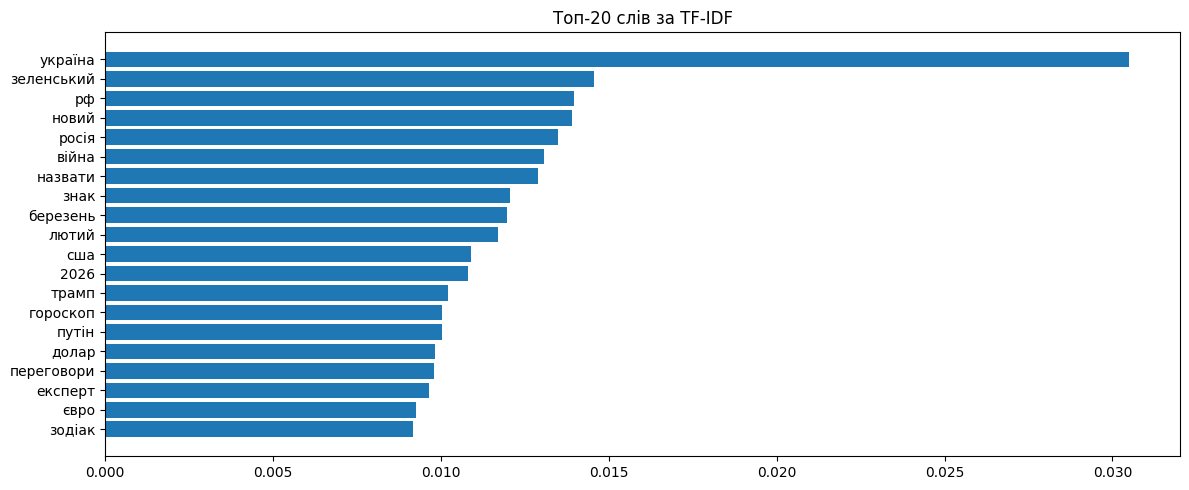

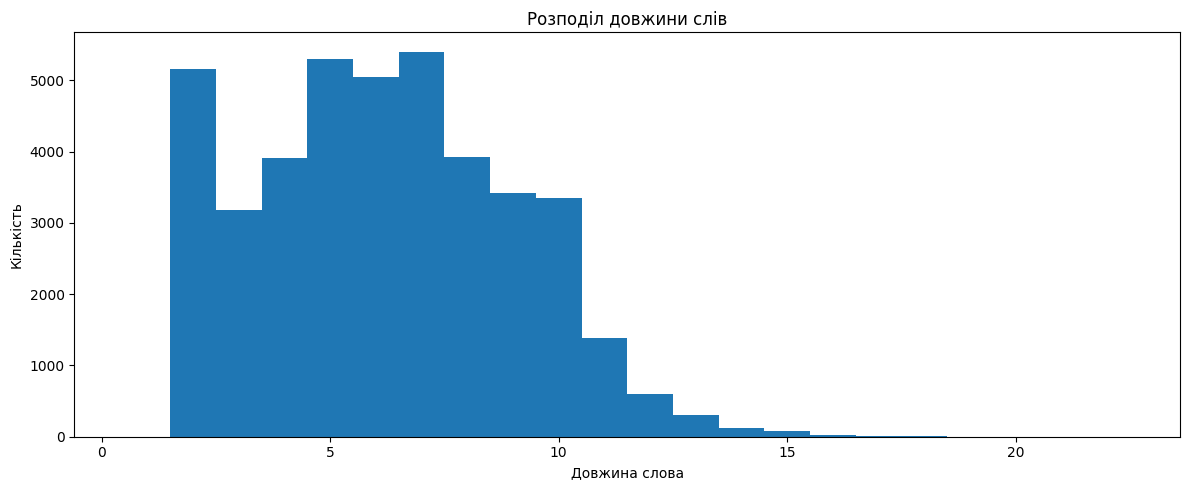

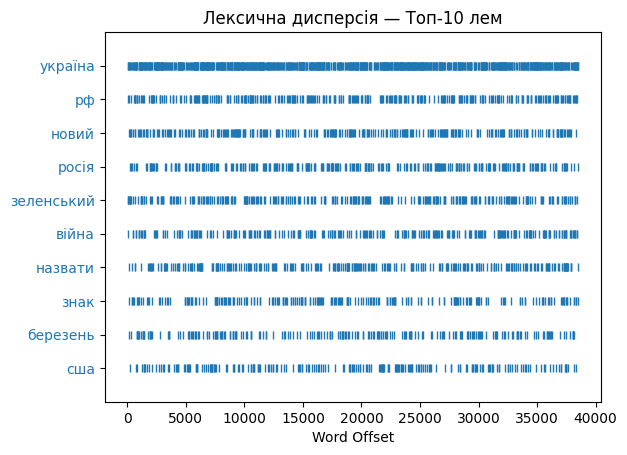

In [8]:
import re
import matplotlib.pyplot as plt
from collections import Counter
from nltk import FreqDist, bigrams
from nltk.draw.dispersion import dispersion_plot
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np


def load_unique(path):
    """Завантажує сирі заголовки з unique.txt без міток і службових слів."""
    headlines = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            split = line.split()
            if not split:
                continue
            split.pop(0)
            for _ in range(6):
                if split:
                    split.pop(0)
            headlines.append(" ".join(split))
    return headlines


def load_lemmatized(path):
    """Завантажує лематизовані рядки з файлу."""
    with open(path, 'r', encoding='utf-8') as f:
        return [l.strip() for l in f if l.strip()]


headlines = load_unique("unique.txt")
lemmatized = load_lemmatized("lemmatized.txt")
all_lemmas = [w for line in lemmatized for w in line.split()]
all_words = [w for h in headlines for w in h.split() if re.match(r'^[а-яіїєґА-ЯІЇЄҐ]{2,}$', w)]

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(lemmatized)
feature_names = vectorizer.get_feature_names_out()
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[::-1][:20]
top_words = [feature_names[i] for i in top_idx]
top_scores = [mean_tfidf[i] for i in top_idx]

plt.figure(figsize=(12, 5))
plt.barh(top_words[::-1], top_scores[::-1])
plt.title('Топ-20 слів за TF-IDF')
plt.tight_layout()
plt.show()

lengths = [len(w) for w in all_words]
plt.figure(figsize=(12, 5))
plt.hist(lengths, bins=range(1, max(lengths) + 2), align='left')
plt.xlabel('Довжина слова')
plt.ylabel('Кількість')
plt.title('Розподіл довжини слів')
plt.tight_layout()
plt.show()

top10 = [w for w, _ in Counter(all_lemmas).most_common(10)]
dispersion_plot(all_lemmas, top10, title='Лексична дисперсія — Топ-10 лем')
plt.show()




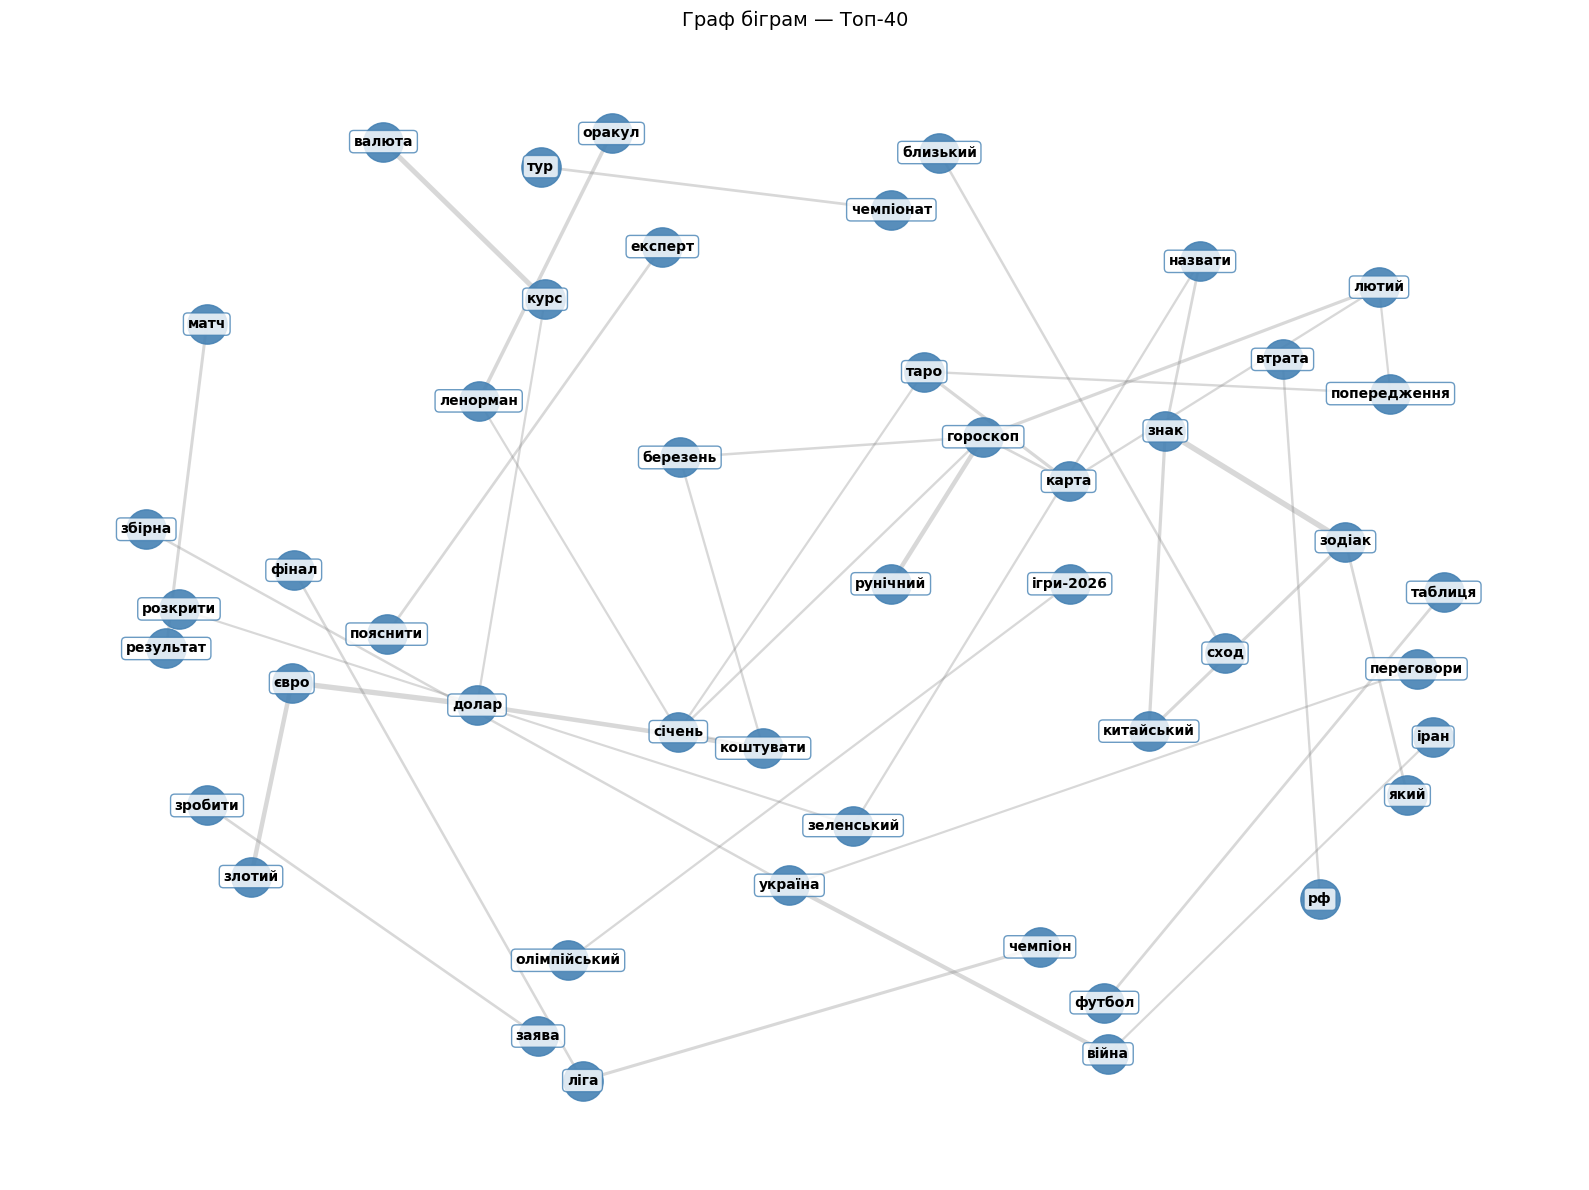

In [12]:
from nltk import bigrams
from collections import Counter
import networkx as nx


all_bigrams = []
for line in lemmatized:
    words = line.split()
    all_bigrams.extend(bigrams(words))


top_bigrams = Counter(all_bigrams).most_common(40)

G = nx.Graph()
for (w1, w2), weight in top_bigrams:
    G.add_edge(w1, w2, weight=weight)


plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, seed=42, k=3)
weights = [G[u][v]['weight'] for u, v in G.edges()]
max_w = max(weights)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray',
                       width=[1 + 3 * w / max_w for w in weights])
nx.draw_networkx_nodes(G, pos, node_size=800,
                       node_color='steelblue', alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=10,
                        font_color='black', font_weight='bold',
                        bbox=dict(boxstyle='round,pad=0.3',
                                  facecolor='white',
                                  edgecolor='steelblue',
                                  alpha=0.8))
plt.title('Граф біграм — Топ-40', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

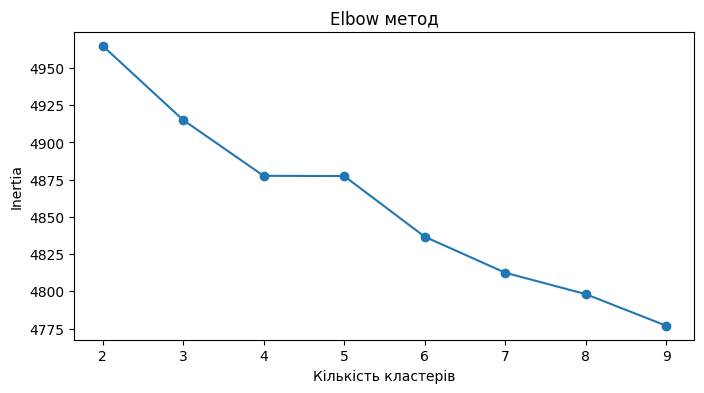

In [15]:
from sklearn.cluster import KMeans
inertia = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 10), inertia, 'o-')
plt.title('Elbow метод')
plt.xlabel('Кількість кластерів')
plt.ylabel('Inertia')
plt.show()

Silhouette Score: 0.012547269596240833


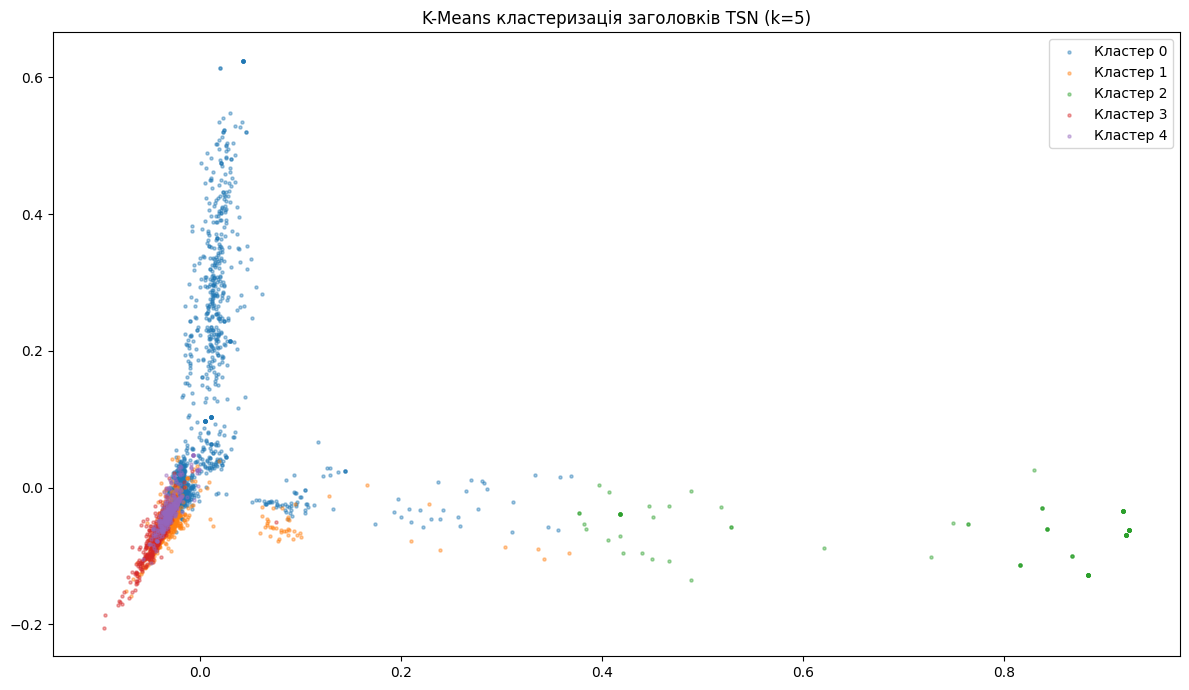

In [16]:

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

vectorizer_km = TfidfVectorizer(max_features=5000)
X = vectorizer_km.fit_transform(lemmatized)

km = KMeans(n_clusters=5, random_state=42, n_init=10)
km.fit(X)

print("Silhouette Score:", silhouette_score(X, km.labels_, sample_size=5000))

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X.toarray())

plt.figure(figsize=(12, 7))
for i in range(5):
    mask = km.labels_ == i
    plt.scatter(coords[mask, 0], coords[mask, 1], s=5, alpha=0.4, label=f'Кластер {i}')
plt.legend()
plt.title('K-Means кластеризація заголовків TSN (k=5)')
plt.tight_layout()
plt.show()